# 04 — Churn Insights Report
**Telco Customer Churn Analysis · Future Interns Task 2 · 2026**

---

> This is the **boardroom notebook** — designed to be presented to a product manager, startup founder, or business stakeholder. It summarises the five highest-impact findings from the analysis and translates them into concrete, prioritised recommendations.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.family': 'DejaVu Sans'
})

df = pd.read_csv('../dataset/cleaned/telco_churn_clean.csv')
bins   = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12m', '13-24m', '25-36m', '37-48m', '49-60m', '61-72m']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, ordered=True)
print("Data loaded. Ready to generate executive report.")

Data loaded. Ready to generate executive report.


---
## Executive Summary

**Business context:** Customer churn directly reduces revenue without any corresponding reduction in acquisition cost. For a SaaS or subscription business, reducing churn by even 5 percentage points can increase annual revenue by 6–8% through improved retention economics.

**What this analysis found:** Churn in the Telco dataset is not random — it is **heavily concentrated in identifiable, actionable segments**. The analysis identified four independent variables that, in combination, predict the vast majority of churn risk.

---

In [2]:
# ── EXECUTIVE KPI SUMMARY ──
kpis = {
    'Total Customers':         f"{len(df):,}",
    'Churned Customers':       f"{df['Churn_bin'].sum():,}",
    'Overall Churn Rate':      f"{df['Churn_bin'].mean()*100:.1f}%",
    'Avg CLV (Two-year)':      f"${df[df['Contract']=='Two year']['CLV'].mean():,.0f}",
    'Avg CLV (Month-to-month)':f"${df[df['Contract']=='Month-to-month']['CLV'].mean():,.0f}",
    'CLV Uplift (2yr vs M2M)': f"{df[df['Contract']=='Two year']['CLV'].mean() / df[df['Contract']=='Month-to-month']['CLV'].mean():.1f}x",
    'Highest Churn Segment':   "Electronic check (45.3%)",
    'Lowest Churn Segment':    "Two-year contract (2.8%)",
}
print("=" * 50)
print("  EXECUTIVE KPI SUMMARY")
print("=" * 50)
for k, v in kpis.items():
    print(f"  {k:<32} {v}")
print("=" * 50)

  EXECUTIVE KPI SUMMARY
  Total Customers                  7,032
  Churned Customers                1,869
  Overall Churn Rate               26.6%
  Avg CLV (Two-year)               $3,729
  Avg CLV (Month-to-month)         $1,370
  CLV Uplift (2yr vs M2M)          2.7x
  Highest Churn Segment            Electronic check (45.3%)
  Lowest Churn Segment             Two-year contract (2.8%)


---
## Finding 1 — Contract Type is the #1 Churn Driver

Month-to-month customers churn at **42.7%** — 15× higher than two-year contract holders. This single variable is more predictive than any other feature in the dataset.

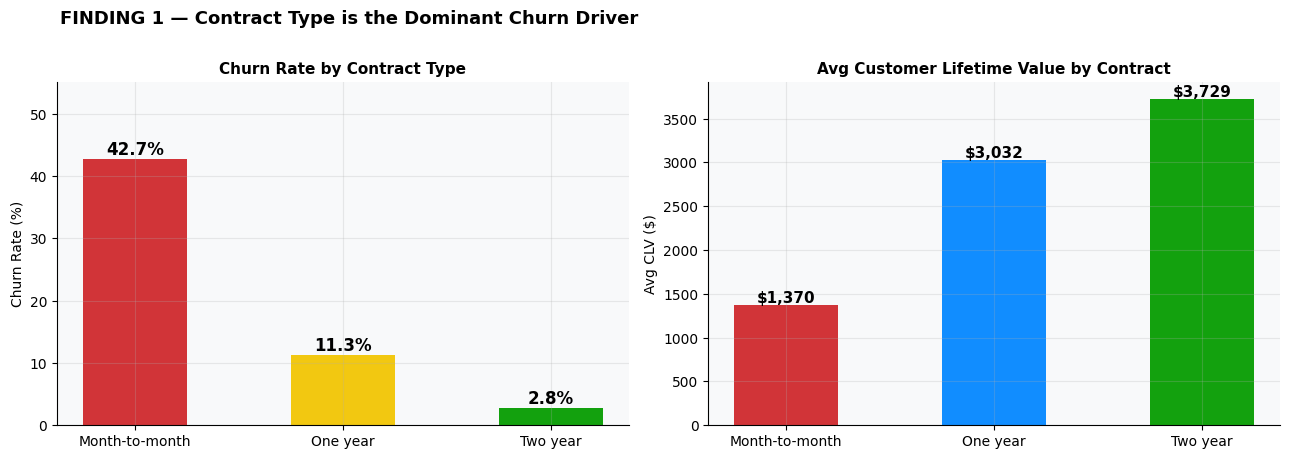

Business implication: Every M2M→Annual upgrade is worth ~$1,660 in additional lifetime revenue.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('FINDING 1 — Contract Type is the Dominant Churn Driver',
             fontsize=13, fontweight='bold', x=0.05, ha='left', y=1.01)

# Churn rate
contract_churn = df.groupby('Contract')['Churn_bin'].mean().reindex(
    ['Month-to-month','One year','Two year']) * 100
bars = axes[0].bar(contract_churn.index, contract_churn.values,
                   color=['#d13438','#f2c811','#13a10e'], edgecolor='none', width=0.5)
axes[0].set_title('Churn Rate by Contract Type', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 55)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.7,
                 f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=12)

# CLV
clv = df.groupby('Contract')['CLV'].mean().reindex(['Month-to-month','One year','Two year'])
bars2 = axes[1].bar(clv.index, clv.values,
                    color=['#d13438','#118dff','#13a10e'], edgecolor='none', width=0.5)
axes[1].set_title('Avg Customer Lifetime Value by Contract', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Avg CLV ($)')
for bar in bars2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'${bar.get_height():,.0f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/figures/report_f1_contract.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Business implication: Every M2M→Annual upgrade is worth ~$1,660 in additional lifetime revenue.")

---
## Finding 2 — The First Year is a Crisis Window

**47.7% of customers in their first 12 months churn.** By year five, that figure falls to 6.6%. The business is haemorrhaging customers before they have generated meaningful revenue.

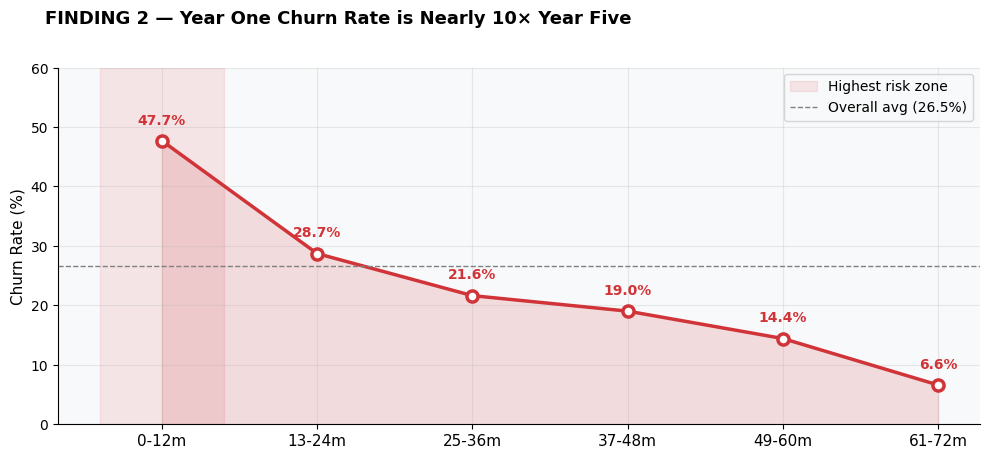

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
fig.suptitle('FINDING 2 — Year One Churn Rate is Nearly 10× Year Five',
             fontsize=13, fontweight='bold', x=0.05, ha='left', y=1.01)

cohort_churn = df.groupby('tenure_group', observed=True)['Churn_bin'].mean() * 100
ax.fill_between(range(len(cohort_churn)), cohort_churn.values,
                alpha=0.15, color='#d13438')
ax.plot(range(len(cohort_churn)), cohort_churn.values,
        color='#d13438', linewidth=2.5, marker='o', markersize=8,
        markerfacecolor='white', markeredgecolor='#d13438', markeredgewidth=2.5)

# Highlight year 1
ax.axvspan(-0.4, 0.4, alpha=0.1, color='#d13438', label='Highest risk zone')
ax.set_xticks(range(len(cohort_churn)))
ax.set_xticklabels(cohort_churn.index, fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 60)
ax.axhline(df['Churn_bin'].mean()*100, color='grey', linestyle='--',
           linewidth=1, label='Overall avg (26.5%)')
ax.legend()
for i, (idx, v) in enumerate(cohort_churn.items()):
    ax.annotate(f'{v:.1f}%', xy=(i, v), xytext=(0, 12),
                textcoords='offset points', ha='center',
                color='#d13438', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/report_f2_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Finding 3 — Add-on Services Dramatically Reduce Churn

Customers with OnlineSecurity churn at **14.6%** vs **41.8%** without — a 65% reduction. TechSupport shows a near-identical pattern. These are not just revenue add-ons — they are **retention anchors**.

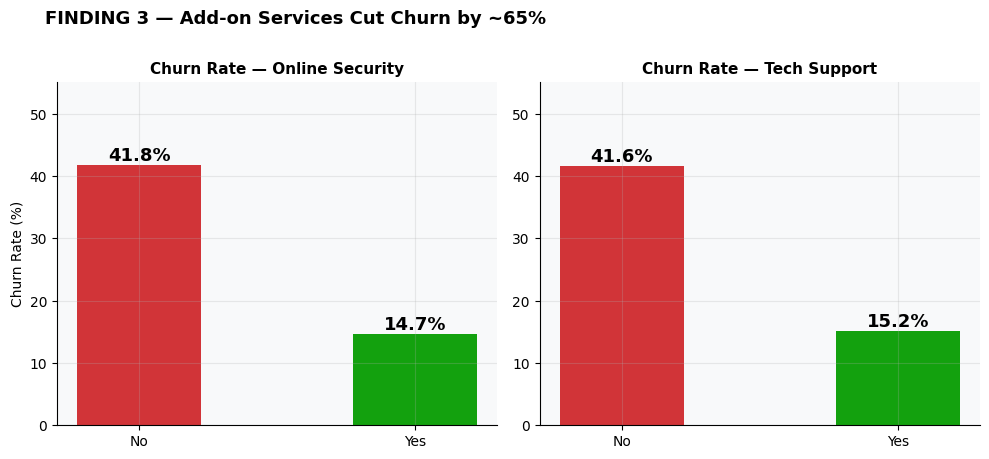

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle('FINDING 3 — Add-on Services Cut Churn by ~65%',
             fontsize=13, fontweight='bold', x=0.05, ha='left', y=1.01)

for i, (col, title) in enumerate([('OnlineSecurity', 'Online Security'),
                                    ('TechSupport', 'Tech Support')]):
    rates = df[df[col].isin(['Yes','No'])].groupby(col)['Churn_bin'].mean() * 100
    colors = ['#d13438' if idx=='No' else '#13a10e' for idx in rates.index]
    bars = axes[i].bar(rates.index, rates.values, color=colors, edgecolor='none', width=0.45)
    axes[i].set_title(f'Churn Rate — {title}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)' if i == 0 else '')
    axes[i].set_ylim(0, 55)
    for bar in bars:
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.7,
                     f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('../reports/figures/report_f3_addons.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Finding 4 — Payment Method Signals Commitment

Electronic check users churn at **45.3%** — nearly 3× the rate of auto-pay users (~16%). Payment method is both a churn predictor and a commitment signal. Customers who automate payments are removing friction from their own relationship with the service.

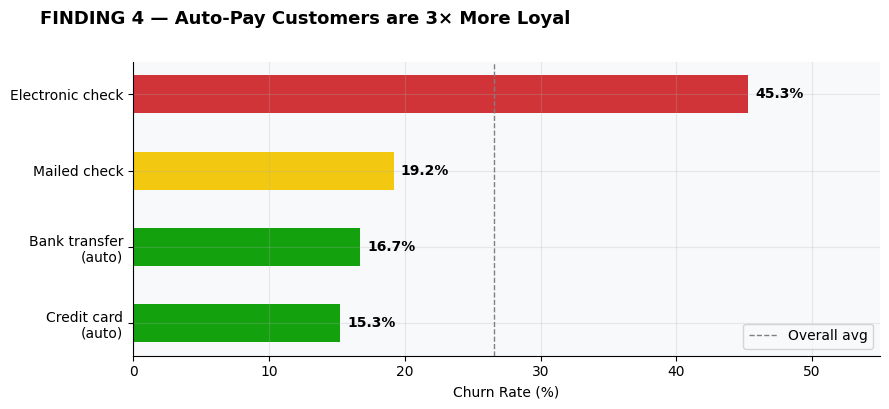

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('FINDING 4 — Auto-Pay Customers are 3× More Loyal',
             fontsize=13, fontweight='bold', x=0.05, ha='left', y=1.01)

pay_churn = df.groupby('PaymentMethod')['Churn_bin'].mean().sort_values(ascending=True) * 100
colors = ['#13a10e' if '(automatic)' in p else '#d13438' if p == 'Electronic check'
          else '#f2c811' for p in pay_churn.index]
bars = ax.barh([p.replace(' (automatic)', '\n(auto)') for p in pay_churn.index],
               pay_churn.values, color=colors, edgecolor='none', height=0.5)
ax.set_xlabel('Churn Rate (%)')
ax.set_xlim(0, 55)
ax.axvline(df['Churn_bin'].mean()*100, color='grey', linestyle='--',
           linewidth=1, label='Overall avg')
ax.legend()
for bar in bars:
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/report_f4_payment.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Finding 5 — Fiber Optic is Paying More but Churning More

Fiber optic customers churn at **41.9%** — more than double DSL users — despite paying significantly higher monthly charges. This is the clearest sign of a value perception gap in the dataset.

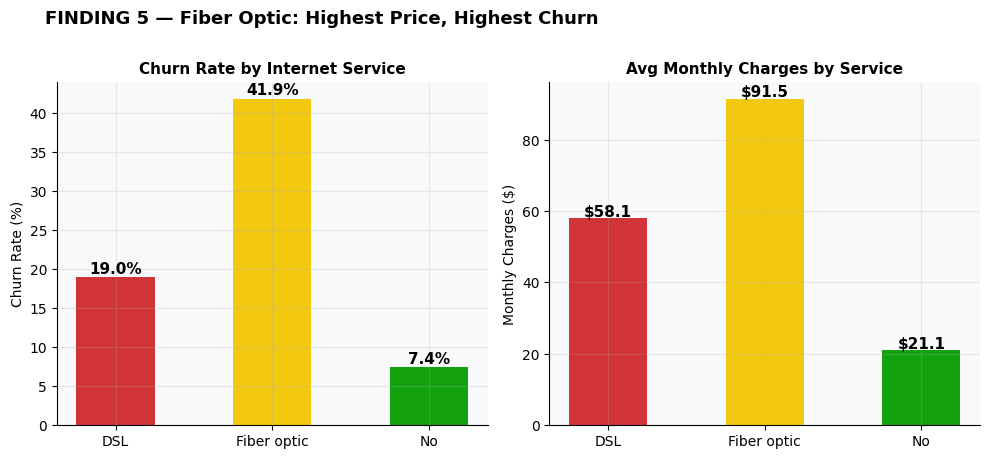

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle('FINDING 5 — Fiber Optic: Highest Price, Highest Churn',
             fontsize=13, fontweight='bold', x=0.05, ha='left', y=1.01)

int_churn = df.groupby('InternetService')['Churn_bin'].mean() * 100
int_charges = df.groupby('InternetService')['MonthlyCharges'].mean()

for ax, data, title, ylabel, color_set in [
    (axes[0], int_churn,   'Churn Rate by Internet Service', 'Churn Rate (%)',
     ['#d13438','#f2c811','#13a10e']),
    (axes[1], int_charges, 'Avg Monthly Charges by Service', 'Monthly Charges ($)',
     ['#d13438','#f2c811','#13a10e'])
]:
    bars = ax.bar(data.index, data.values, color=color_set, edgecolor='none', width=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    for bar in bars:
        label = f'{bar.get_height():.1f}%' if ylabel.startswith('Churn') else f'${bar.get_height():.1f}'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                label, ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/figures/report_f5_fiber.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Strategic Recommendations

Prioritised by impact based on segment size and churn rate differential.

In [8]:
recommendations = [
    {
        'priority': '🔴 HIGH',
        'action': '90-Day Contract Upgrade Campaign',
        'detail': 'At 60-90 days, offer M2M customers 1-2 months free to switch to annual. Target: 0-12m cohort (51.4% churn).',
        'target': 'Month-to-month, 0-12 months',
        'metric': '$1,660 CLV upside per conversion'
    },
    {
        'priority': '🔴 HIGH',
        'action': 'Fiber Optic Satisfaction Audit',
        'detail': 'Run NPS survey for Fiber optic users. If NPS < 30, implement SLA-backed service credits.',
        'target': 'Fiber optic subscribers (3,096 customers)',
        'metric': '41.9% → target <25% churn'
    },
    {
        'priority': '🟡 MEDIUM',
        'action': 'Default Add-on Trial at Onboarding',
        'detail': 'Include 3-month free OnlineSecurity + TechSupport for all new customers. Opt-out, not opt-in.',
        'target': 'All new customers at signup',
        'metric': '65% churn reduction with add-ons'
    },
    {
        'priority': '🟡 MEDIUM',
        'action': 'Auto-Pay Migration Campaign',
        'detail': 'Offer $2-5/month discount to switch from electronic check to auto-pay.',
        'target': 'Electronic check users (2,365 customers)',
        'metric': '45.3% → ~16% churn if converted'
    },
    {
        'priority': '🟢 STRATEGIC',
        'action': 'Build a Churn Early-Warning Score',
        'detail': 'Score customers on: contract type + tenure + payment + add-on count. Flag top-risk for proactive outreach.',
        'target': 'All customers, ongoing',
        'metric': 'Turns this analysis into a repeatable process'
    },
]

print("=" * 70)
print("  STRATEGIC RECOMMENDATIONS — PRIORITISED BY IMPACT")
print("=" * 70)
for i, r in enumerate(recommendations, 1):
    print(f"\n  {r['priority']} — Recommendation {i}")
    print(f"  Action  : {r['action']}")
    print(f"  Detail  : {r['detail']}")
    print(f"  Target  : {r['target']}")
    print(f"  Metric  : {r['metric']}")
print()
print("=" * 70)

  STRATEGIC RECOMMENDATIONS — PRIORITISED BY IMPACT

  🔴 HIGH — Recommendation 1
  Action  : 90-Day Contract Upgrade Campaign
  Detail  : At 60-90 days, offer M2M customers 1-2 months free to switch to annual. Target: 0-12m cohort (51.4% churn).
  Target  : Month-to-month, 0-12 months
  Metric  : $1,660 CLV upside per conversion

  🔴 HIGH — Recommendation 2
  Action  : Fiber Optic Satisfaction Audit
  Detail  : Run NPS survey for Fiber optic users. If NPS < 30, implement SLA-backed service credits.
  Target  : Fiber optic subscribers (3,096 customers)
  Metric  : 41.9% → target <25% churn

  🟡 MEDIUM — Recommendation 3
  Action  : Default Add-on Trial at Onboarding
  Detail  : Include 3-month free OnlineSecurity + TechSupport for all new customers. Opt-out, not opt-in.
  Target  : All new customers at signup
  Metric  : 65% churn reduction with add-ons

  🟡 MEDIUM — Recommendation 4
  Action  : Auto-Pay Migration Campaign
  Detail  : Offer $2-5/month discount to switch from electronic 

---
## If I Were the Founder

Three things I would do **this week** based on this analysis:

1. **Pull the high-risk list now.** Every customer who is month-to-month + 30–90 days old + electronic check payment. That is your most urgent retention cohort. Email or call them personally with an upgrade offer this week.

2. **Change one default.** Make OnlineSecurity opt-out instead of opt-in for new customers. The data says customers with this service are 3× more likely to stay. One product change, lasting impact.

3. **Set one north-star metric.** Track the percentage of new customers who convert from month-to-month to annual within 90 days. That number predicts your retention health 6 months before churn data shows it.

---

*Analysis completed as part of Future Interns — Data Science & Analytics Internship (2026), Task 2.*  
*Dataset: Telco Customer Churn (Kaggle) · 7,032 customers · 21 features*